## Bayesian Analysis

A **Bayesian posterior distribution** was conducted on the 2011 Census dataset to analyse and model the **"Economically active"** population.

The model uses key socio-economic factors such as **working-age population, retired population, car ownership, commuting distance, and unemployment** as predictors.

This approach enables probabilistic estimation of the target variable and provides insights into the relationships and uncertainty within the data.

In [ ]:
from google.colab import drive # connecting collab with drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pymc arviz  # installing library


In [ ]:
# Import libraries for data handling and Bayesian modelling
# pandas: data manipulation
# pymc: Bayesian modelling
# arviz: analysis and visualization of Bayesian results

import pandas as pd
import pymc as pm
import arviz as az

In [ ]:
df = pd.read_csv(r"/content/drive/MyDrive/Colab Notebooks/Cleaned_Data/Data.csv") #reading data

In [ ]:
df.head(5) # first five rows

,Unnamed: 0,geography,geography code,Rural Urban,Cars: No cars or vans in household; measures: Value,Cars: 1 car or van in household; measures: Value,Cars: 2 cars or vans in household; measures: Value,Cars: 3 cars or vans in household; measures: Value,Cars: 4 or more cars or vans in household; measures: Value,Distance travelled to work: Less than 2km; measures: Value,...,Distance (Work from home),Distance < 10 km,10 km < Distance < 30 km,30 km < Distanc < 60 km,Unemployed,Economically active,Economically Inactive,cluster,P1,P2
0,0,Darlington,E06000005,Total,13052,20682,10450,1962,524,11433,...,4180,28175,9962,3529,4002,49441,23192,3,8.120296,-2.323253
1,1,County Durham,E06000047,Total,60926,96086,52740,10775,3276,36588,...,20652,106475,71001,14772,17013,230088,136695,0,8.916958,-3.204791
2,2,Hartlepool,E06000001,Total,14268,16573,7662,1535,396,8452,...,2473,22415,7391,2324,5194,38319,23291,0,9.162120,-4.377292
3,3,Middlesbrough,E06000002,Total,21488,22963,10207,1945,600,10393,...,3337,37606,5418,3223,7631,55951,36969,0,9.813269,-5.781488
4,4,Northumberland,E06000057,Total,30543,60875,36916,7671,2529,25944,...,17894,60003,43224,15421,10329,147939,74956,1,6.843403,-0.309240


In [ ]:
df.columns.tolist()

['Unnamed: 0',
 'geography',
 'geography code',
 'Rural Urban',
 'Cars: No cars or vans in household; measures: Value',
 'Cars: 1 car or van in household; measures: Value',
 'Cars: 2 cars or vans in household; measures: Value',
 'Cars: 3 cars or vans in household; measures: Value',
 'Cars: 4 or more cars or vans in household; measures: Value',
 'Distance travelled to work: Less than 2km; measures: Value',
 'Distance travelled to work: 2km to less than 5km; measures: Value',
 'Distance travelled to work: 5km to less than 10km; measures: Value',
 'Distance travelled to work: 10km to less than 20km; measures: Value',
 'Distance travelled to work: 20km to less than 30km; measures: Value',
 'Distance travelled to work: 30km to less than 40km; measures: Value',
 'Distance travelled to work: 40km to less than 60km; measures: Value',
 'Distance travelled to work: 60km and over; measures: Value',
 'Distance travelled to work: Work mainly at or from home; measures: Value',
 'Distance travelled t

In [ ]:
# Select distance-related features
# Convert values to proportions by normalising each row

df_dist = df[["Distance < 10 km", "10 km < Distance < 30 km", "30 km < Distanc < 60 km"]]
df_dist = df_dist.div(df_dist.sum(axis=1), axis=0)
df_dist = df_dist.drop(["30 km < Distanc < 60 km"], axis=1)

In [ ]:
# Select age-related features
# Convert values to proportions by normalising each row

df_age = df[['Young 0-19',
 'Working-age 20-64',
 'Retired-age 65-90']]
df_age = df_age.div(df_age.sum(axis=1), axis=0)
df_age = df_age.drop(["Young 0-19"], axis=1)


In [ ]:
# Select economy-related features
# Convert values to proportions by normalising each row
df_eco = df[['Unemployed',
 'Economically active',
 'Economically Inactive']]
df_eco = df_eco.div(df_eco.sum(axis=1), axis=0)
df_eco = df_eco.drop(['Economically Inactive'], axis=1)
df_eco = df_eco.drop(['Economically Inactive'], axis=1)


In [ ]:
# Select car-related features
# Convert values to proportions by normalising each row
df_car = df[['No Cars and Vans',
 '1 Car or Van',
 '(2, 3, 4) Car or Van']]
df_car = df_car.div(df_car.sum(axis=1), axis=0)
df_car = df_car.drop(['(2, 3, 4) Car or Van'], axis=1)

In [ ]:
df_final = pd.concat([df_age, df_car, df_dist, df_eco], axis = 1) #concatinating

In [ ]:
df_final.head(5) # first five rows

,Working-age 20-64,Retired-age 65-90,No Cars and Vans,1 Car or Van,Distance < 10 km,10 km < Distance < 30 km,Unemployed,Economically active
0,0.585806,0.174671,0.279666,0.443154,0.676211,0.239092,0.052222,0.645149
1,0.595290,0.179925,0.272230,0.429333,0.553842,0.369320,0.044328,0.599506
2,0.582529,0.169492,0.352871,0.409878,0.697635,0.230034,0.077750,0.573603
3,0.588569,0.149488,0.375645,0.401430,0.813155,0.117154,0.075892,0.556444
4,0.582970,0.200311,0.220473,0.439423,0.505723,0.364304,0.044288,0.634322


In [ ]:
y = df_final["Economically active"]   #target

In [ ]:
X = df[["Working-age 20-64",	"Retired-age 65-90", 	"No Cars and Vans",	"1 Car or Van",	"Distance < 10 km",	"10 km < Distance < 30 km",	"Unemployed"]] #Predictors

In [ ]:
# Standardize features so they have mean = 0 and standard deviation = 1

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
# Define Bayesian linear regression model
with pm.Model() as employment_model:
    
    # Priors for intercept and coefficients
    alpha = pm.Normal('intercept', mu=0, sigma=10)
    beta = pm.Normal('beta', mu=0, sigma=10, shape=X.shape[1])

    # Prior for noise (standard deviation, must be positive)
    sigma = pm.Exponential('sigma', 1.0)

    # Linear model: expected value of target
    mu = alpha + pm.math.dot(X.values, beta)

    # Likelihood: observed target data
    likelihood = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y.values)

    # Sample from posterior distribution
    trace = pm.sample(draws=2000, tune=2000, target_accept=0.99, random_seed=42)

# Summarize and visualize posterior results
print(az.summary(trace, round_to=2))
az.plot_posterior(trace)

In [ ]:
import pymc as pm
import arviz as az
import pandas as pd

# Standardize features (Z-score scaling) to improve model stability
X_scaled = (X - X.mean()) / X.std()

# Define improved Bayesian linear regression model
with pm.Model() as improved_model:
    
    # Priors for intercept and coefficients (tighter priors for better convergence)
    alpha = pm.Normal('intercept', mu=y.mean(), sigma=1)
    beta = pm.Normal('beta', mu=0, sigma=1, shape=X_scaled.shape[1])
    
    # Prior for noise (standard deviation, constrained to be positive)
    sigma = pm.HalfNormal('sigma', sigma=1)

    # Linear model (expected value)
    mu = alpha + pm.math.dot(X_scaled.values, beta)

    # Likelihood using observed target variable
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y.values)

    # Sample from posterior with higher target_accept for stability
    trace = pm.sample(draws=2000, tune=2000, target_accept=0.99, random_seed=42)

# Display summary of posterior estimates
print(az.summary(trace, round_to=3))

Output()

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]    0.049  0.039  -0.024    0.120      0.001    0.001  1728.896   
beta[1]   -0.064  0.020  -0.100   -0.025      0.000    0.000  2133.497   
beta[2]   -0.011  0.009  -0.026    0.006      0.000    0.000  2462.525   
beta[3]    0.016  0.036  -0.055    0.081      0.001    0.001  2040.506   
beta[4]    0.041  0.021   0.002    0.080      0.000    0.000  1853.821   
beta[5]    0.028  0.013   0.003    0.053      0.000    0.000  1843.042   
beta[6]   -0.060  0.010  -0.078   -0.041      0.000    0.000  2873.520   
intercept  0.648  0.003   0.643    0.653      0.000    0.000  3119.120   
sigma      0.034  0.002   0.030    0.037      0.000    0.000  3282.394   

           ess_tail  r_hat  
beta[0]    2175.543  1.001  
beta[1]    2423.276  1.003  
beta[2]    2626.861  1.002  
beta[3]    2044.191  1.002  
beta[4]    2024.382  1.001  
beta[5]    2117.508  1.001  
beta[6]    2896.808  1.001  
intercept  2591.071  1.000 

array([[<Axes: title={'center': 'beta\n0'}>,
        <Axes: title={'center': 'beta\n1'}>,
        <Axes: title={'center': 'beta\n2'}>],
       [<Axes: title={'center': 'beta\n3'}>,
        <Axes: title={'center': 'beta\n4'}>,
        <Axes: title={'center': 'beta\n5'}>],
       [<Axes: title={'center': 'beta\n6'}>,
        <Axes: title={'center': 'intercept'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

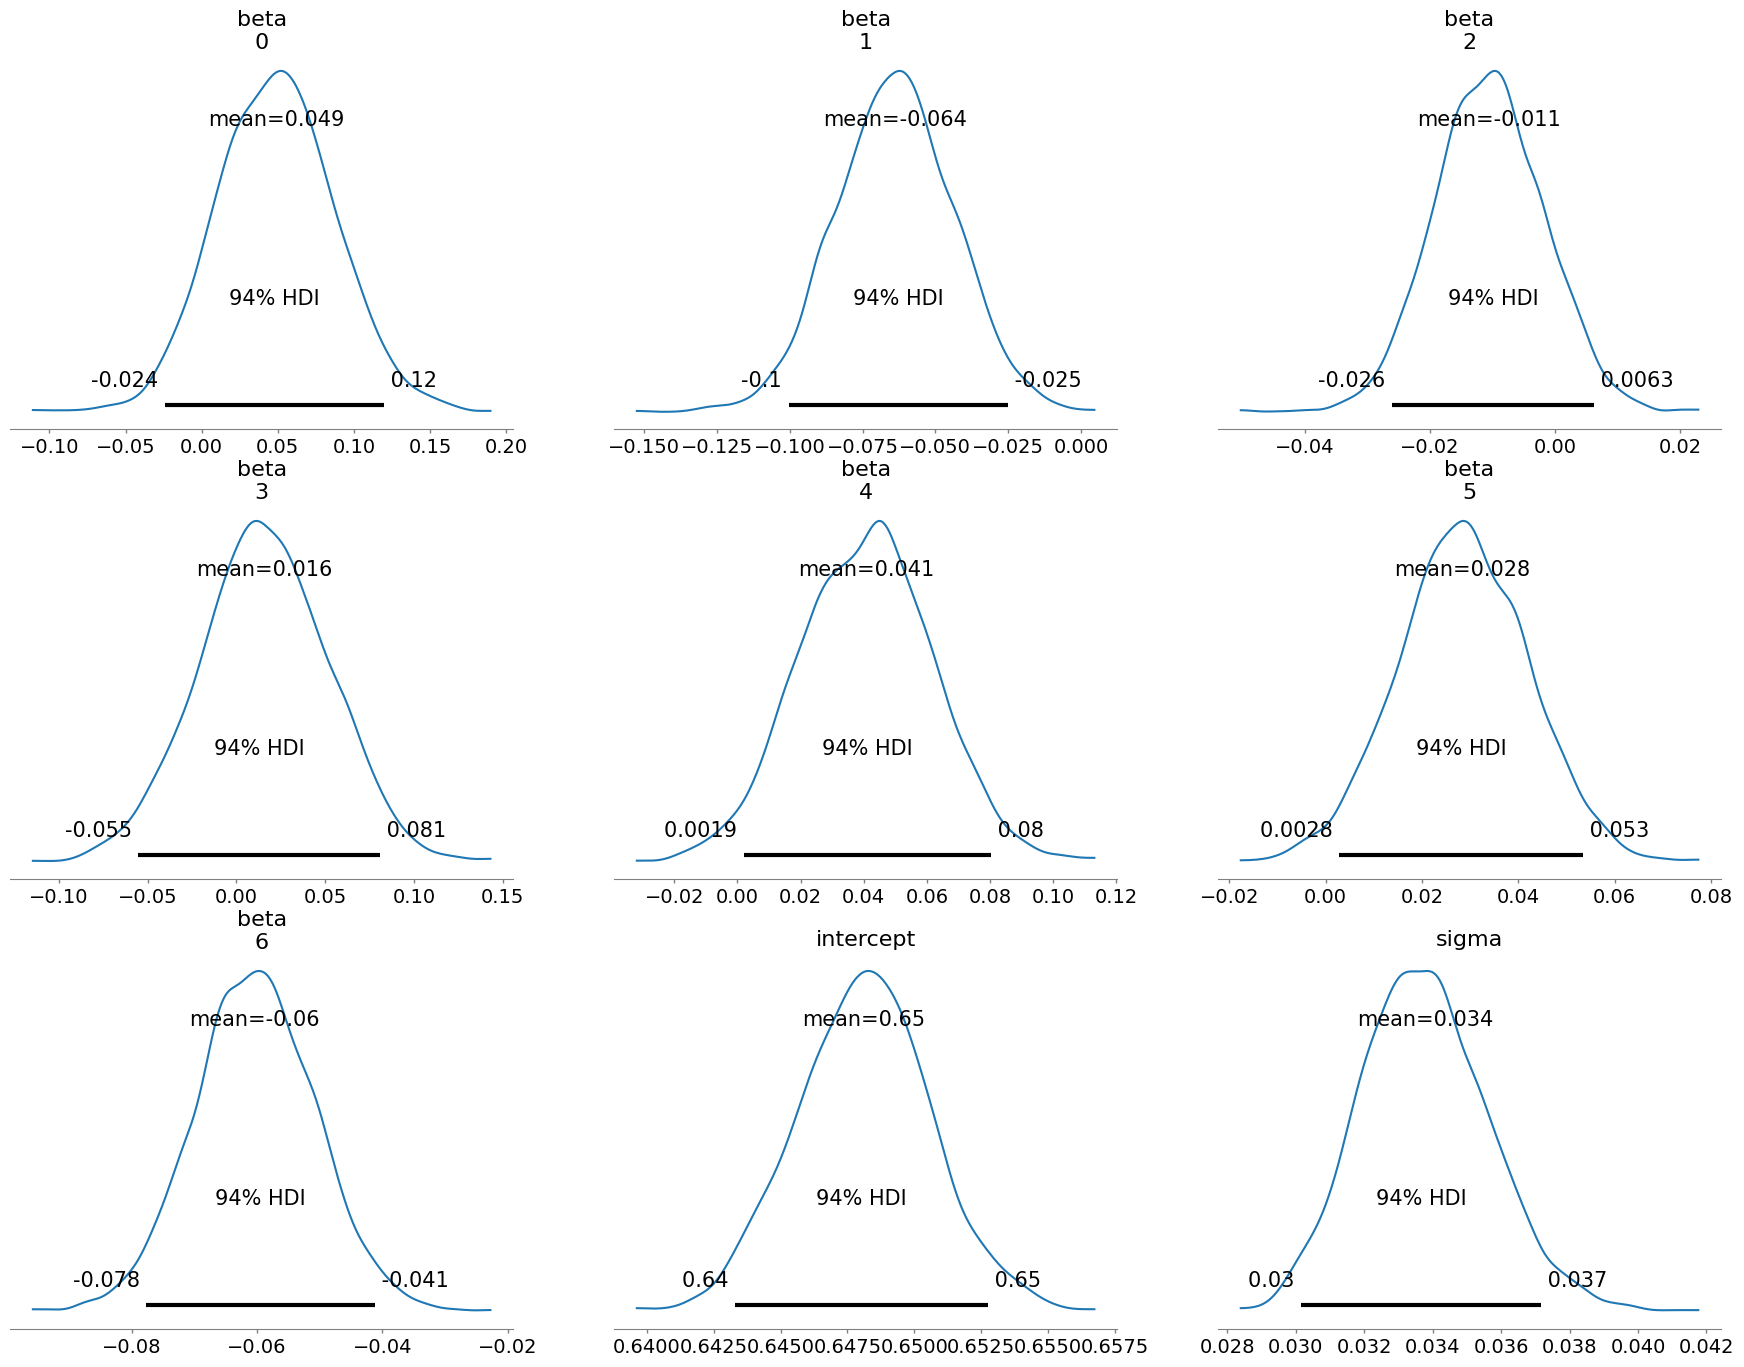

In [ ]:
az.plot_posterior(trace) # plotting the graph

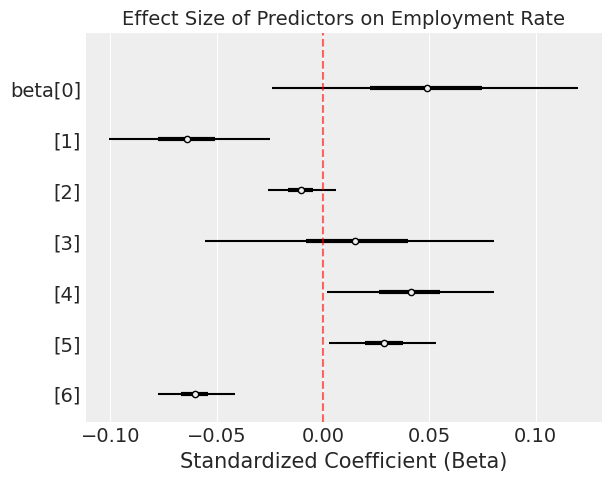

In [ ]:
# Import libraries for posterior analysis and plotting
import arviz as az
import matplotlib.pyplot as plt

# Set plot style for better visual appearance
az.style.use("arviz-darkgrid")

# Create forest plot for beta coefficients (predictor effects)
axes = az.plot_forest(
    trace,
    var_names=['beta'],   # focus only on predictor coefficients
    combined=True,
    colors='black',
    hdi_prob=0.94         # 94% highest density interval
)

# Add vertical reference line at zero (no effect)
plt.axvline(0, color='red', linestyle='--', alpha=0.6)

# Add title and axis label
plt.title('Effect Size of Predictors on Employment Rate', fontsize=14)
plt.xlabel('Standardized Coefficient (Beta)')

# Display the plot
plt.show()
